# CMU Simulation Model

Implements the Capital Markets Union (CMU) model following `v4 CMU_Model_Step_by_Step.md`.

**Country conventions:**
- `i` = origin country (investor / source of capital)
- `j` = destination country (receives capital)

This matches the data column suffixes: `_i` = origin, `_j` = destination.

**Data source:** `Data/Clean/Final-v4.csv`


In [54]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

import warnings
warnings.filterwarnings('ignore')

In [55]:
df = pd.read_csv('Data/Clean/Final-v4.csv')

df["M_i"] = df["M_i"] / 1e6
df["M_j"] = df["M_j"] / 1e6

print(f'Loaded: {df.shape[0]:,} rows, {df.shape[1]} columns')
print(f'Years:  {df["year"].min()} - {df["year"].max()}')

Loaded: 482,160 rows, 44 columns
Years:  2017 - 2024


In [56]:
df[["d_ling", "d_cul", "d_geo"]].isna().mean()

d_ling    0.396964
d_cul     0.983010
d_geo     0.079642
dtype: float64

In [57]:
import pycountry

# Make sure all iso3_i and iso3_j exists
# in pycountry alpha3
# PyCountry mapping
records = []
iso3_vals = []
for c in pycountry.countries:
    records.append({
        "country_name": c.name,
        "iso3":         c.alpha_3,
        "iso2":         c.alpha_2,
        "iso_numeric":  c.numeric,
    })
    iso3_vals.append(c.alpha_3)

df = df[(df["iso3_i"].isin(iso3_vals)) & (df["iso3_j"].isin(iso3_vals))]

In [58]:
df[["d_ling"]].isna().mean()

d_ling    0.344843
dtype: float64

In [59]:
# # Impute the hard frictions that do not change,
# # get the mean average and apply this.
# fric_cols = ["d_geo", "d_ling", "d_cul"]
# df = df.sort_values(["iso3_i", "iso3_j", "year"])
# for c in tqdm(fric_cols):
#     df[c] = df[c].replace(0, np.nan)
#     df[c] = df.groupby(["iso3_i", "iso3_j"])[c].transform(lambda x: x.mean())
# 
# df[fric_cols].isna().mean()

In [60]:
# Prepare logs and features
df["ln_a_ij"] = np.log(df["a_ij"])
df["ln_a_ij_lag1"] = np.log(df["a_ij_lag1"])
df["ln_d_geo"] = np.log(df["d_geo"])

df["euro_ij"] = df["euro_i"] * df["euro_j"]


# Set a dummy variable if languages are very simialr
df['common_lang'] = (df['d_ling'] < 0.2).astype(int)

In [61]:
df[["d_ling"]].isna().mean()

d_ling    0.344843
dtype: float64

In [62]:
monetary_cols = [
    "a_ij", "a_ij_lag1",
    "Y_i", "Y_j", "M_i", "M_j",
    "k_i", "k_j"
]
df[monetary_cols].mean()

a_ij         1.347174e+03
a_ij_lag1    1.387970e+03
Y_i          8.158197e+05
Y_j          8.114459e+05
M_i          1.256842e+06
M_j          1.256842e+06
k_i          3.858354e+06
k_j          3.837194e+06
dtype: float64

In [63]:
# Fix df_full to only be countries that we have defined it to be
# ── Country set: EU-27 + 4 outside options ────────────────────────────────
EU27 = [
    'AUT','BEL','BGR','HRV','CYP','CZE','DNK','EST','FIN','FRA','DEU','GRC',
    'HUN','IRL','ITA','LVA','LTU','LUX','MLT','NLD','POL','PRT','ROU','SVK',
    'SVN','ESP','SWE'
]
OUTSIDE = ['USA','GBR','CHE','NOR']
COUNTRIES = EU27 + OUTSIDE          # n = 31

OECD = [
    'AUS', 'AUT', 'BEL', 'CAN', 'CHL', 'COL', 'CZE', 'DNK', 'EST', 'FIN',
    'FRA', 'DEU', 'GRC', 'HUN', 'ISL', 'IRL', 'ISR', 'ITA', 'JPN', 'KOR',
    'LVA', 'LTU', 'LUX', 'MEX', 'NLD', 'NZL', 'NOR', 'POL', 'PRT', 'SVK',
    'SVN', 'ESP', 'SWE', 'CHE', 'TUR', 'GBR', 'USA'
]

# COUNTRIES = ["FRA", "SWE", "POL"] # Debugging purposes

n = len(COUNTRIES)

In [64]:
# df = df[df["iso3_i"].isin(COUNTRIES) & df["iso3_j"].isin(COUNTRIES)].copy()

In [65]:
df[["d_ling"]].isna().mean()

d_ling    0.344843
dtype: float64

In [66]:
# Compute a_ij as M_i - sum(a_ij) where i≠j
foreign_a = df[df["iso3_i"] != df["iso3_j"]].groupby(["iso3_i", "year"])["a_ij"].sum().reset_index()
foreign_a["foreign_a"] = foreign_a["a_ij"]
del foreign_a["a_ij"]
foreign_a["iso3_j"] = foreign_a["iso3_i"]

foreign_a = foreign_a[["iso3_i", "iso3_j", "year", "foreign_a"]]

# And home bias is M - foreign_a
dom = df[df["iso3_i"]==df["iso3_j"]].copy()

# join foreign onto
dom = dom.merge(foreign_a, left_on=["iso3_i", "iso3_j", "year"], right_on=["iso3_i", "iso3_j", "year"])

# Make a mapper iso3: foreign_a
iso3_to_foreign_a = dict(zip(foreign_a["iso3_i"], foreign_a["foreign_a"]))

# Now for when i=j in df, set a_ij to foreign_a
for iso3 in COUNTRIES:
    mask = (df["iso3_i"] == iso3) & (df["iso3_j"] == iso3)
    if iso3 in iso3_to_foreign_a:
        df.loc[mask, "a_ij"] = iso3_to_foreign_a[iso3]

In [67]:
df[["d_ling", "d_geo", "d_cul"]].isna().mean()

d_ling    0.344843
d_geo     0.000000
d_cul     0.981536
dtype: float64

In [68]:
# Compute the lagged a_ij_lag1
df = df.sort_values(by=["iso3_i", "iso3_j", "year"])
df["a_ij_lag1"] = df.groupby(["iso3_i", "iso3_j"])["a_ij"].shift(1)

In [69]:
df[["d_ling"]].isna().mean()

d_ling    0.344843
dtype: float64

In [70]:
# -- Get base year as the last year ----------------------------------------------
BASE_YEAR = 2023
base = df[df['year'] == BASE_YEAR].copy()
base = base[base["iso3_i"].isin(COUNTRIES) & base["iso3_j"].isin(COUNTRIES)].copy()
print(f'Base year for simulation: {BASE_YEAR}  ({base.shape[0]:,} rows)')

Base year for simulation: 2023  (961 rows)


In [71]:
base

,iso3_i,iso3_j,year,a_ij,M_i,M_j,d_cul,r_i,r_j,Y_i,...,lang_share,lang_official,euro_i,euro_j,d_ling,ln_a_ij,ln_a_ij_lag1,ln_d_geo,euro_ij,common_lang
25694,AUT,AUT,2023,2.762565e+04,138633.49,138633.49,0.000000,0.206228,0.206228,5.757506e+05,...,1.000000,1.0,1.0,1.0,0.000000,NaN,NaN,-inf,1.0,1
25718,AUT,BEL,2023,1.326000e+01,138633.49,NaN,70.971825,0.206228,0.074447,5.757506e+05,...,NaN,NaN,1.0,1.0,NaN,2.584752,2.584752,6.662404,1.0,0
25758,AUT,BGR,2023,1.911650e+02,138633.49,7840.63,NaN,0.206228,NaN,5.757506e+05,...,0.252644,0.0,1.0,0.0,0.836704,5.253137,5.253137,6.939559,0.0,0
25886,AUT,CHE,2023,1.679600e+02,138633.49,2044693.28,NaN,0.206228,0.176668,5.757506e+05,...,0.840214,1.0,1.0,0.0,0.325743,5.123726,5.123726,6.003414,0.0,0
26022,AUT,CYP,2023,1.105000e+00,138633.49,10380.13,NaN,0.206228,NaN,5.757506e+05,...,0.477987,0.0,1.0,1.0,0.889798,0.099845,0.099845,7.664738,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
452142,USA,ROU,2023,3.080000e+02,48979397.70,47864.70,NaN,0.177234,NaN,2.497715e+07,...,0.284894,0.0,0.0,0.0,0.742230,5.730100,5.730100,9.108338,0.0,0
452286,USA,SVK,2023,1.170000e+02,48979397.70,NaN,NaN,0.177234,NaN,2.497715e+07,...,0.315098,0.0,0.0,1.0,0.846084,4.762174,4.762174,9.051169,0.0,0
452294,USA,SVN,2023,4.000000e+00,48979397.70,10108.90,NaN,0.177234,NaN,2.497715e+07,...,0.555622,0.0,0.0,1.0,0.828601,1.386294,1.386294,9.042940,0.0,0
452302,USA,SWE,2023,1.063100e+04,48979397.70,NaN,69.627581,0.177234,0.250690,2.497715e+07,...,0.857268,0.0,0.0,0.0,0.586448,9.271530,9.271530,8.902577,0.0,0


In [72]:
base.isna().mean().sort_values(ascending=False)

d_cul                 0.765869
M_j                   0.483871
M_i                   0.483871
r_j                   0.419355
r_i                   0.419355
language_proximity    0.155047
lang_official         0.122789
d_ling                0.122789
lang_share            0.122789
ln_a_ij               0.042664
ln_a_ij_lag1          0.042664
bis_debt_i            0.032258
a_ij_lag1             0.006243
a_ij                  0.006243
iso3_i                0.000000
iso3_j                0.000000
year                  0.000000
rf_i                  0.000000
A_i                   0.000000
delta_i               0.000000
lab_sh_i              0.000000
pop_i                 0.000000
L_i                   0.000000
k_i                   0.000000
Y_i                   0.000000
lab_sh_j              0.000000
pop_j                 0.000000
inv_share_i           0.000000
hc_i                  0.000000
k_j                   0.000000
L_j                   0.000000
alpha_i               0.000000
Y_j     

In [73]:
base.head(5)

,iso3_i,iso3_j,year,a_ij,M_i,M_j,d_cul,r_i,r_j,Y_i,...,lang_share,lang_official,euro_i,euro_j,d_ling,ln_a_ij,ln_a_ij_lag1,ln_d_geo,euro_ij,common_lang
25694,AUT,AUT,2023,27625.648395,138633.49,138633.49,0.000000,0.206228,0.206228,575750.625,...,1.000000,1.0,1.0,1.0,0.000000,NaN,NaN,-inf,1.0,1
25718,AUT,BEL,2023,13.260000,138633.49,NaN,70.971825,0.206228,0.074447,575750.625,...,NaN,NaN,1.0,1.0,NaN,2.584752,2.584752,6.662404,1.0,0
25758,AUT,BGR,2023,191.165000,138633.49,7840.63,NaN,0.206228,NaN,575750.625,...,0.252644,0.0,1.0,0.0,0.836704,5.253137,5.253137,6.939559,0.0,0
25886,AUT,CHE,2023,167.960000,138633.49,2044693.28,NaN,0.206228,0.176668,575750.625,...,0.840214,1.0,1.0,0.0,0.325743,5.123726,5.123726,6.003414,0.0,0
26022,AUT,CYP,2023,1.105000,138633.49,10380.13,NaN,0.206228,NaN,575750.625,...,0.477987,0.0,1.0,1.0,0.889798,0.099845,0.099845,7.664738,1.0,0


In [74]:
# Get nans per columns in base
base.isna().mean().sort_values(ascending=False).head(10)

d_cul                 0.765869
M_j                   0.483871
M_i                   0.483871
r_j                   0.419355
r_i                   0.419355
language_proximity    0.155047
lang_official         0.122789
d_ling                0.122789
lang_share            0.122789
ln_a_ij               0.042664
dtype: float64

In [75]:
A_arr = base.pivot(index='iso3_i', columns='iso3_j', values='a_ij').fillna(0)

A_arr.iloc[0:3, 0:3]

iso3_j,AUT,BEL,BGR
iso3_i,,,
AUT,27625.648395,13.260000,191.165000
BEL,5163.665000,45428.591914,1.105000
BGR,30.619177,0.028993,1936.228876


In [76]:
Pi_data = A_arr / A_arr.sum(axis=1)  # Normalize to get portfolio shares
Pi_data.iloc[0:3, 0:3]

iso3_j,AUT,BEL,BGR
iso3_i,,,
AUT,0.624225,1.592571e-04,0.065515
BEL,0.116677,5.456129e-01,0.000379
BGR,0.000692,3.482209e-07,0.663572


In [77]:
# # -- Plot the A matrix as a heatmap -------------------------------------------------
# plt.figure(figsize=(12, 10))
# sns.heatmap(A_arr.apply(np.log1p), cmap='viridis', cbar_kws={'label': 'a_ij'})
# plt.title('Gravity Model A Matrix (Base Year)')
# plt.xlabel('Country j')
# plt.ylabel('Country i')
# plt.xticks(rotation=90)
# plt.yticks(rotation=0)
# plt.tight_layout()
# plt.show()

In [78]:
# -- Calculate home bias per country ------------------------------------------------------
# This is just the diagonal / sum of row
diag = np.diag(A_arr)
row_sums = A_arr.sum(axis=1)
pi_data = diag / row_sums
pi_data.sort_values(ascending=False).head(3)

iso3_i
USA    0.775468
SWE    0.709511
PRT    0.695266
dtype: float64

In [79]:
# TODO: We are imputing M as the average % of Y. Remove this
avg_sh = np.nanmean(df['M_i'] / df['Y_i'])
df.loc[df['M_i'].isna(), 'M_i'] = df['Y_i'] * avg_sh
base.loc[base['M_i'].isna(), 'M_i'] = base['Y_i'] * avg_sh

In [80]:
# ── Country-level macro variables for base year ───────────────────────────
# Pulled from the origin-side (_i) columns which have better country coverage.
# Each country's A, k, Y, L, alpha, M are the same physical quantities
# regardless of whether the country acts as origin or destination in a given row.
ctry_cols = ['iso3_i', 'M_i', 'k_i', 'Y_i', 'A_i', 'L_i', 'alpha_i', 'delta_i']
ctry = base.drop_duplicates('iso3_i').set_index('iso3_i')[ctry_cols[1:]]
ctry = ctry.reindex(COUNTRIES)

M     = ctry['M_i'].values       # stock market cap  (n,)
k     = ctry['k_i'].values       # capital stock
Y     = ctry['Y_i'].values       # real GDP
A     = ctry['A_i'].values       # TFP
L     = ctry['L_i'].values       # employment
alpha = ctry['alpha_i'].values   # capital share
delta = ctry['delta_i'].values   # depreciation

idx = {c: i for i, c in enumerate(COUNTRIES)}   # country → position index

print(ctry[['M_i', 'k_i', 'Y_i', 'alpha_i']].head(10).to_string())

                 M_i           k_i           Y_i   alpha_i
iso3_i                                                    
AUT     1.386335e+05  3.241278e+06  5.757506e+05  0.392000
BEL     3.518067e+05  3.976496e+06  6.782517e+05  0.413874
BGR     7.840630e+03  5.391208e+05  1.936551e+05  0.483489
HRV     2.535411e+04  7.555801e+05  1.450957e+05  0.387384
CYP     1.038013e+04  2.413204e+05  3.569566e+04  0.463422
CZE     3.466117e+04  2.851752e+06  4.838283e+05  0.488498
DNK     2.056723e+05  1.990346e+06  3.965176e+05  0.398817
EST     2.775536e+04  3.038233e+05  5.350984e+04  0.393288
FIN     1.519228e+05  1.846421e+06  2.928934e+05  0.417123
FRA     1.841068e+06  2.126019e+07  3.549413e+06  0.369021


In [81]:
idx

{'AUT': 0,
 'BEL': 1,
 'BGR': 2,
 'HRV': 3,
 'CYP': 4,
 'CZE': 5,
 'DNK': 6,
 'EST': 7,
 'FIN': 8,
 'FRA': 9,
 'DEU': 10,
 'GRC': 11,
 'HUN': 12,
 'IRL': 13,
 'ITA': 14,
 'LVA': 15,
 'LTU': 16,
 'LUX': 17,
 'MLT': 18,
 'NLD': 19,
 'POL': 20,
 'PRT': 21,
 'ROU': 22,
 'SVK': 23,
 'SVN': 24,
 'ESP': 25,
 'SWE': 26,
 'USA': 27,
 'GBR': 28,
 'CHE': 29,
 'NOR': 30}

## Step 1. Gravity Model

In [94]:
# -- Prepare panel: all years, off-diagonal, country set ---------------------
grav = df[
    df["iso3_j"].isin(COUNTRIES) &
    df["iso3_i"].isin(COUNTRIES) &
    (df["iso3_j"] != df["iso3_i"])
].copy()

# Replace inf with nan
grav = grav.replace([np.inf, -np.inf], np.nan)

# Require positive a_ij for log transformation
# NOTE: We do not need to log anything since ppml 
# runs y = exp(Xβ))
grav = grav[grav["a_ij"]>0]
grav = grav[grav["a_ij_lag1"]>0]

reg_cols = ["a_ij", "a_ij_lag1", "d_geo", "d_cul", "d_ling", "euro_ij"
            , "iso3_i", "iso3_j", "year", "ln_a_ij", "ln_a_ij_lag1"
            , "ln_d_geo", "common_lang"]
grav_reg = grav[reg_cols].dropna().copy()
print(f'Regression sample: {len(grav_reg):,} observations across {grav_reg["year"].nunique()} years')

Regression sample: 1,082 observations across 7 years


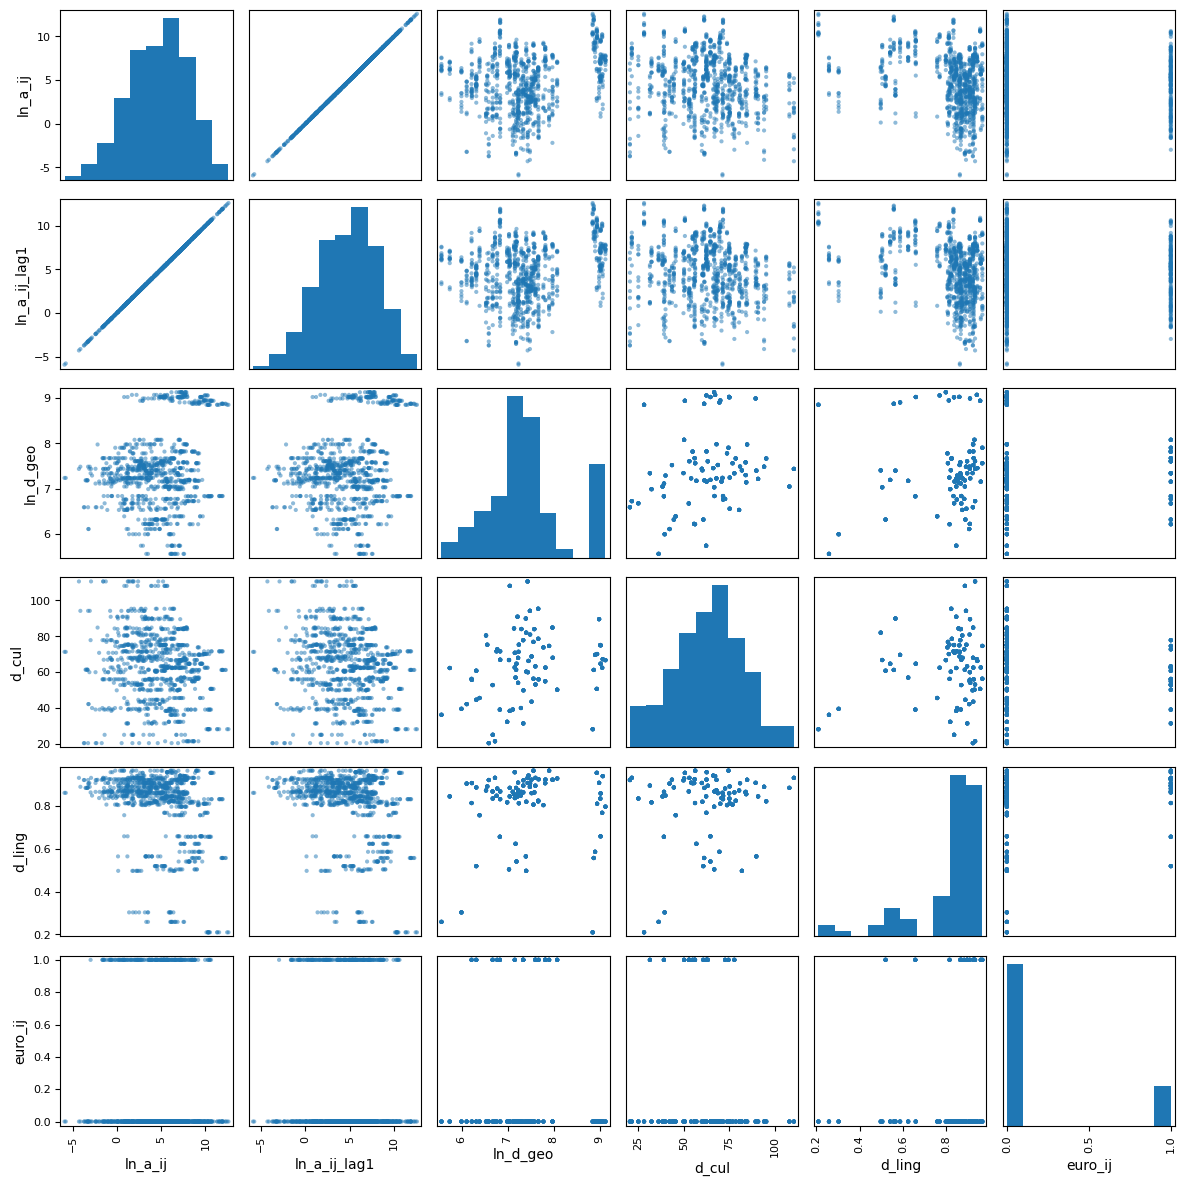

In [95]:
# scatter matrix plot the grav_reg
from pandas.plotting import scatter_matrix

plot_cols = ["ln_a_ij", "ln_a_ij_lag1", "ln_d_geo", "d_cul", "d_ling", "euro_ij"]
scatter_matrix(grav_reg[plot_cols].sample(min(1000, len(grav_reg))), figsize=(12, 12))
plt.tight_layout()
plt.show()

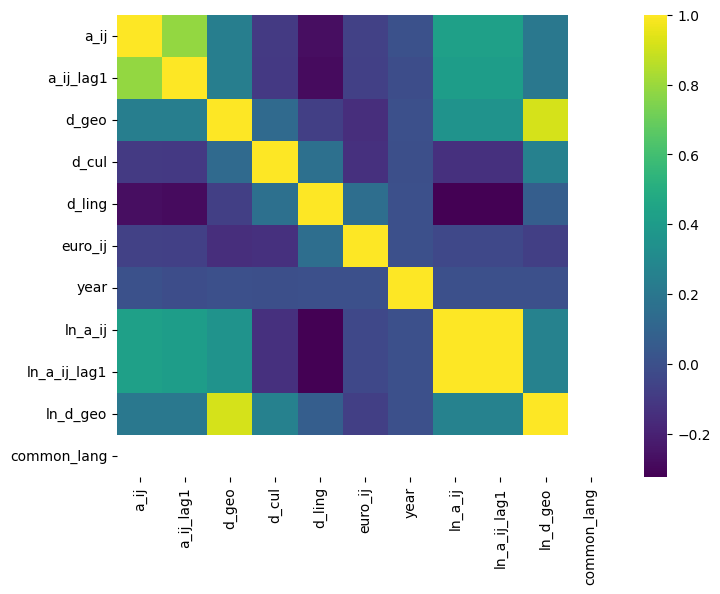

In [96]:
# Get a correlation matrix between the columns
num_cols = grav_reg.select_dtypes(include=['number']).columns

plt.figure(figsize=(8,6))
sns.heatmap(grav_reg[num_cols].corr(), cmap="viridis")
plt.show()

In [101]:
# -- Panel with destination FE, origin FE, year FE --------------------------------
formula = (
    'a_ij ~ ln_d_geo + euro_ij'
    '+ C(iso3_i) + C(iso3_j) + C(year)'
)

ppml = smf.poisson(formula, data=grav_reg).fit(
    cov_type='cluster',
    cov_kwds={'groups': grav_reg['iso3_i'].astype(str) + '_' + grav_reg['iso3_j'].astype(str)}
)

beta_a      = ppml.params.get('a_ij_lag1', 0)
beta_geo    = ppml.params.get('ln_d_geo', 0)
beta_cul    = ppml.params.get('d_cul', 0)
beta_ling   = ppml.params.get('d_ling', 0)
beta_coml   = ppml.params.get("common_lang", 0)
beta_euro   = ppml.params.get('euro_ij', 0)

# Store them in a dictionary for easy access
# and if we change coefficients we can still
# run the code without changing hardcoded 
# variable namess
beta_coef_dict = {
    'ln_d_geo': beta_geo,
    'd_ling': beta_ling,
    'd_cul': beta_cul,
    'common_lang': beta_coml,
    'euro_ij': beta_euro
}

# coefficient, p-value:.3f, t-stat in parentheses
print(ppml.summary().tables[0])
print(f'β_a   (a_ij_lag1)       : {beta_a:.3f}   p={ppml.pvalues.get("a_ij_lag1", 0):.3f}')
print(f'β_geo  (ln_d_geo)       : {beta_geo:.3f}   p={ppml.pvalues.get("ln_d_geo", 0):.3f}')
print(f'β_cul  (d_cul)          : {beta_cul:.3f}   p={ppml.pvalues.get("d_cul", 0):.3f}')
print(f'β_ling (d_ling)         : {beta_ling:.3f}  p={ppml.pvalues.get("d_ling", 0):.3f}')
print(f'β_commonlang            : {beta_coml:.3f}  p={ppml.pvalues.get("common_lang", 0):.3f}')
print(f'β_euro (euro_ij)        : {beta_euro:.3f}  p={ppml.pvalues.get("euro_ij", 0):.3f}')

Optimization terminated successfully.
         Current function value: 2477.597073
         Iterations 13
                          Poisson Regression Results                          
Dep. Variable:                   a_ij   No. Observations:                 1082
Model:                        Poisson   Df Residuals:                     1049
Method:                           MLE   Df Model:                           32
Date:                Thu, 02 Apr 2026   Pseudo R-squ.:                  0.7872
Time:                        15:02:36   Log-Likelihood:            -2.6808e+06
converged:                       True   LL-Null:                   -1.2596e+07
Covariance Type:              cluster   LLR p-value:                     0.000
β_a   (a_ij_lag1)       : 0.000   p=0.000
β_geo  (ln_d_geo)       : -1.335   p=0.003
β_cul  (d_cul)          : 0.000   p=0.000
β_ling (d_ling)         : 0.000  p=0.000
β_commonlang            : 0.000  p=0.000
β_euro (euro_ij)        : 0.469  p=0.577


In [102]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = grav_reg[beta_coef_dict.keys()].dropna()
vif_data = pd.DataFrame({
    'feature': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
print(vif_data)

       feature        VIF
0     ln_d_geo  28.342621
1       d_ling  23.492577
2        d_cul  13.609939
3  common_lang        NaN
4      euro_ij   1.306266


## Step 2: Bilateral wedges

For every pair $(i,j)$ where $i≠j$, compute:
$$\ln{\Delta^{baseline}_{ij}} = 
(-\hat{\beta}_1) \times \ln{d_{ij}^{geo}}
+ (-\hat{\beta}_2) \times \ln{d_{ij}^{cul}}
+ (-\hat{\beta}_3) \times Euro_{ij}
$$

Then exponentiate:
$$\Delta^{baseline}_{ij} = exp(\ln{\Delta^{baseline}_{ij}})$$

**Interpretation**: $\Delta_{ij}>0$ means there is a friction. As a larger value means larger friction.

In [103]:
# TODO: Do we assume that we get it as ln_delta or is it level? From PPML
Delta_arr = np.ones((n, n))

for _, row in tqdm(base.iterrows(), total=len(base)):
    i, j = row['iso3_i'], row['iso3_j']
    
    if i == j:
        continue
    if i not in COUNTRIES or j not in COUNTRIES:
        continue
    
    ii, jj = idx[i], idx[j]
    
    # Compute the ln_delta by summing
    # up the beta_coef_dict with the
    # respective number. First run checks
    ln_delta = 0
    if "ln_d_geo" in beta_coef_dict and not np.isnan(row["ln_d_geo"]):
        ln_delta -= beta_coef_dict["ln_d_geo"] * row["ln_d_geo"]
    if "d_ling" in beta_coef_dict and not np.isnan(row["d_ling"]):
        ln_delta -= beta_coef_dict["d_ling"] * row["d_ling"]
    if "d_cul" in beta_coef_dict and not np.isnan(row["d_cul"]):
        ln_delta -= beta_coef_dict["d_cul"] * row["d_cul"]
    if "euro_ij" in beta_coef_dict and not np.isnan(row["euro_ij"]):
        ln_delta -= beta_coef_dict["euro_ij"] * row["euro_ij"]
    if "common_lang" in beta_coef_dict and not np.isnan(row["common_lang"]):
        ln_delta -= beta_coef_dict["common_lang"] * row["common_lang"]

    Delta_arr[ii, jj] = np.exp(ln_delta)


Delta_arr[0:3, 0:3]

  0%|          | 0/961 [00:00<?, ?it/s]

100%|██████████| 961/961 [00:00<00:00, 4184.75it/s]


array([[1.00000000e+00, 4.57579643e+03, 1.05877994e+04],
       [4.57579643e+03, 1.00000000e+00, 2.23837760e+04],
       [1.05877994e+04, 2.23837760e+04, 1.00000000e+00]])

In [104]:
# ── Returns R_j = MPK_j = α_j * Y_j / k_j, normalised to mean = 1 ────────
# These are destination j characteristics for the portfolio model.
# Pulled from _i columns (origin-side, better base-year coverage) — values are
# identical for the same country regardless of origin/destination role.
ctry_base = df[df['year'] == BASE_YEAR].drop_duplicates('iso3_i').set_index('iso3_i')
ctry_base = ctry_base.reindex(COUNTRIES)

R_vec = (ctry_base['alpha_i'] * ctry_base['Y_i'] / ctry_base['k_i']).values.astype(float)
M_vec = ctry_base['M_i'].values.astype(float)

# Fill missing with cross-country medians
R_vec = np.where(np.isnan(R_vec), np.nanmedian(R_vec), R_vec)
M_vec = np.where(np.isnan(M_vec) | (M_vec <= 0), np.nanmedian(M_vec[M_vec > 0]), M_vec)

# Normalise R so mean = 1
R_vec = R_vec / R_vec.mean()

print('Returns R_j (destination, normalised):')
print(pd.Series(R_vec, index=COUNTRIES).sort_values(ascending=False).head(10))

Returns R_j (destination, normalised):
IRL    2.135736
POL    1.879900
BGR    1.835670
MLT    1.741946
NOR    1.553549
ROU    1.493808
USA    1.410109
LUX    1.073863
NLD    1.031733
LTU    1.030665
dtype: float64


In [105]:
# ── Calibrate diagonal Δ_ii to match observed home bias ──────────────────
# π_ii = (R_i^η * M_i / Δ_ii) / Σ_ι (R_ι^η * M_ι / Δ_iι)
# Iterative update: Δ_ii ← Δ_ii * (π̂_ii / π_ii^data)
# Skipped for: invalid origins (NaN π_ii) and degenerate cases (π_ii = 0 or ≥ 1)
eta = 1.0

pi_home = np.diag(Pi_data)   # observed home bias π_ii; NaN for invalid origins

# Initialise: small wedge only for calibratable origins, 1.0 (neutral) otherwise
for i, ci in enumerate(COUNTRIES):
    if (ci in COUNTRIES
            and not np.isnan(pi_home[i])
            and 0 < pi_home[i] < 0.9999):
        Delta_arr[i, i] = 0.01
    else:
        Delta_arr[i, i] = 1.0

RM = (R_vec ** eta) * M_vec   # destination attractiveness weights (n,)

MAX_ITER = 10_000
TOL      = 1e-4

for iteration in range(MAX_ITER):
    max_err = 0.0
    for i, ci in enumerate(COUNTRIES):
        if np.isnan(pi_home[i]) or pi_home[i] <= 0 or pi_home[i] >= 0.9999:
            continue
        # Row i of Delta: attractiveness of each destination j for origin i
        w = RM / Delta_arr[i, :]
        Z_i = w.sum()
        pi_hat_ii = w[i] / Z_i
        Delta_arr[i, i] *= pi_hat_ii / pi_home[i]
        max_err = max(max_err, abs(pi_hat_ii - pi_home[i]))
    if max_err < TOL:
        print(f'Converged in {iteration+1} iterations (max error = {max_err:.6f})')
        break
else:
    print(f'Did not fully converge after {MAX_ITER} iterations (max error = {max_err:.6f})')

Delta_baseline = Delta_arr.copy()

calibrated = [c for c in COUNTRIES
              if not np.isnan(pi_home[COUNTRIES.index(c)])
              and 0 < pi_home[COUNTRIES.index(c)] < 0.9999]
print('\nCalibrated diagonal wedges (Δ_ii):')
print(pd.Series(np.diag(Delta_baseline), index=COUNTRIES)[calibrated]
      .sort_values(ascending=False).to_string())
skipped = [c for c in COUNTRIES if c not in calibrated]
print(f'\nSkipped (π_ii = 0 or ≥ 1, Δ_ii = 1): {skipped}')


Converged in 67 iterations (max error = 0.000084)

Calibrated diagonal wedges (Δ_ii):
USA    601897.870109
DEU       714.064209
GBR       702.349382
ITA       620.166834
IRL       523.144166
FRA       313.514823
CHE       300.847404
POL       246.518428
ESP       157.067708
NLD       131.486722
SWE       101.189821
DNK        97.839263
NOR        93.667377
FIN        74.588825
ROU        50.469922
BEL        50.354302
PRT        41.229396
SVK        33.630943
GRC        31.104829
LTU        26.279277
AUT        19.913621
HUN        17.375910
CZE        11.468892
LUX         8.236671
LVA         7.706413
HRV         7.518020
MLT         7.205526
BGR         7.097104
EST         6.905280
CYP         5.488264
SVN         1.491766

Skipped (π_ii = 0 or ≥ 1, Δ_ii = 1): []


## Step 4: Baseline portfolio shares

In [106]:
def compute_portfolio(Delta, R, M, eta):
    """
    Compute n×n portfolio share matrix.
      Rows = origin i, columns = destination j.
      π_ij = (R_j^η * M_j / Δ_ij) / Σ_ι (R_ι^η * M_ι / Δ_iι)
    """
    RM = (R ** eta) * M                  # (n,) destination attractiveness weights
    W  = RM[np.newaxis, :] / Delta       # (n, n)  W[i,j] = RM_j / Δ_ij
    Z  = W.sum(axis=1)                   # (n,)    row sums Z_i
    Pi = W / Z[:, np.newaxis]            # (n, n)  row-normalised shares
    return Pi

Pi_baseline = compute_portfolio(Delta_baseline, R_vec, M_vec, eta)

# Validation: diagonal π_ii should match observed home bias for calibrated origins
pi_base_home = np.diag(Pi_baseline)
comparison = pd.DataFrame({
    'π_data':     np.diag(Pi_data),
    'π_baseline': pi_base_home,
    'diff':        pi_base_home - np.diag(Pi_data)
}, index=COUNTRIES)
print('Home bias: data vs. baseline (calibrated origins only)')
print(comparison.dropna(subset=['π_data']).sort_values('π_data', ascending=False).round(4).to_string())

# Off-diagonal correlation — valid origins only (their rows are non-NaN)
mask   = ~np.eye(n, dtype=bool)
valid_i = np.array([c in COUNTRIES for c in COUNTRIES])  # Fixed: removed duplicate 'in'
mask_valid = mask & valid_i[:, np.newaxis]   # valid-origin rows only
pd_vals = Pi_data.values[mask_valid]  # Convert to numpy array
pb_vals = Pi_baseline[mask_valid]  # Convert to numpy array
finite  = np.isfinite(pd_vals) & np.isfinite(pb_vals)
corr = np.corrcoef(pd_vals[finite], pb_vals[finite])[0, 1]
print(f'\nOff-diagonal correlation (data vs baseline, valid origins): {corr:.4f}')

Home bias: data vs. baseline (calibrated origins only)
     π_data  π_baseline    diff
NOR  0.7755      0.7755  0.0001
CHE  0.7095      0.7095  0.0000
ESP  0.6953      0.6953  0.0000
EST  0.6844      0.6844  0.0000
BGR  0.6636      0.6636  0.0000
SWE  0.6621      0.6621  0.0000
CYP  0.6502      0.6502  0.0000
AUT  0.6242      0.6242  0.0000
PRT  0.6232      0.6232  0.0000
FRA  0.6202      0.6202  0.0000
LTU  0.6146      0.6146  0.0000
USA  0.5952      0.5952  0.0000
LVA  0.5867      0.5867  0.0000
GRC  0.5866      0.5866  0.0000
SVN  0.5836      0.5836  0.0000
SVK  0.5742      0.5742  0.0000
LUX  0.5660      0.5660  0.0000
HRV  0.5656      0.5656  0.0000
GBR  0.5633      0.5633  0.0000
ROU  0.5613      0.5613  0.0000
NLD  0.5598      0.5598  0.0000
CZE  0.5516      0.5516  0.0000
FIN  0.5511      0.5511  0.0000
BEL  0.5456      0.5456  0.0000
HUN  0.5427      0.5427  0.0000
POL  0.5281      0.5281  0.0000
ITA  0.5249      0.5249  0.0000
DEU  0.5042      0.5042  0.0000
MLT  0.4970      

## Step 5-6: CMU Shock and Counterfactual Positions

In [107]:
# EU membership flags for the CMU shock
eu_flag = np.array([int(c in EU27) for c in base["iso3_i"].unique()])   # (n,)
# Intra-EU off-diagonal pair mask
eu_pair = np.outer(eu_flag, eu_flag) * (1 - np.eye(n))   # (n, n)

PHI_SCENARIOS = [0.25, 0.50, 0.75, 1.00]

results = {}   # keyed by phi

for phi in PHI_SCENARIOS:
    # Δ^CMU = Δ^baseline^(1-phi)  for intra-EU off-diagonal, else unchanged
    Delta_cmu = Delta_baseline.copy()
    Delta_cmu = np.where(eu_pair.astype(bool),
                         Delta_baseline ** (1 - phi),
                         Delta_baseline)

    Pi_cmu = compute_portfolio(Delta_cmu, R_vec, M_vec, eta)
    results[phi] = {'Delta_cmu': Delta_cmu, 'Pi_cmu': Pi_cmu}

print('CMU scenarios computed for φ =', PHI_SCENARIOS)

CMU scenarios computed for φ = [0.25, 0.5, 0.75, 1.0]


In [108]:
# ── Change in home bias ΔHomeBias_j = π_jj^CMU - π_jj^baseline ───────────
home_bias_table = pd.DataFrame({'π_baseline': np.diag(Pi_baseline)}, index=COUNTRIES)
for phi in PHI_SCENARIOS:
    Pi_cmu = results[phi]['Pi_cmu']
    home_bias_table[f'π_CMU(φ={phi})']  = np.diag(Pi_cmu)
    home_bias_table[f'Δπ(φ={phi})']     = np.diag(Pi_cmu) - np.diag(Pi_baseline)

print('Home bias change by φ (EU27 only):')
eu_mask = [c in EU27 for c in COUNTRIES]
print(home_bias_table.loc[eu_mask].round(4).to_string())

Home bias change by φ (EU27 only):
     π_baseline  π_CMU(φ=0.25)  Δπ(φ=0.25)  π_CMU(φ=0.5)  Δπ(φ=0.5)  π_CMU(φ=0.75)  Δπ(φ=0.75)  π_CMU(φ=1.0)  Δπ(φ=1.0)
AUT      0.6242         0.1516     -0.4726        0.0153    -0.6089         0.0011     -0.6231        0.0001    -0.6242
BEL      0.5456         0.1273     -0.4183        0.0139    -0.5317         0.0011     -0.5446        0.0001    -0.5455
BGR      0.6636         0.1219     -0.5417        0.0085    -0.6551         0.0005     -0.6631        0.0000    -0.6635
HRV      0.5656         0.5656      0.0000        0.5656     0.0000         0.5656      0.0000        0.5656     0.0000
CYP      0.6502         0.1033     -0.5469        0.0064    -0.6438         0.0003     -0.6498        0.0000    -0.6502
CZE      0.5516         0.1033     -0.4483        0.0088    -0.5428         0.0006     -0.5510        0.0000    -0.5516
DNK      0.4743         0.0739     -0.4004        0.0059    -0.4685         0.0004     -0.4739        0.0000    -0.4743
EST  

## Step 7: Capital reallocation

In [109]:
# s_i = total equity portfolio of origin i (held fixed across scenarios)
s_vec = A_arr.sum(axis=1).reindex(COUNTRIES).values

# k_j^baseline = Σ_i π_ij^baseline * s_i  (capital received by destination j)
# In matrix form: k = Π^T · s  (column j of Π dotted with s)
k_baseline = Pi_baseline.T @ s_vec   # (n,)

capital_table = pd.DataFrame({'k_baseline': k_baseline}, index=COUNTRIES)

for phi in PHI_SCENARIOS:
    Pi_cmu = results[phi]['Pi_cmu']
    k_cmu  = Pi_cmu.T @ s_vec
    capital_table[f'k_CMU(φ={phi})']  = k_cmu
    capital_table[f'Δk/k(φ={phi})']   = (k_cmu - k_baseline) / k_baseline
    results[phi]['k_cmu'] = k_cmu

# Conservation check: total capital must be preserved
print('Capital conservation check (CMU total / baseline total):')
for phi in PHI_SCENARIOS:
    ratio = results[phi]['k_cmu'].sum() / k_baseline.sum()
    print(f'  φ={phi}: {ratio:.8f}')

print('\nCapital change (% points) — all countries:')
delta_k_cols = [c for c in capital_table.columns if 'Δk/k' in c]
print((capital_table[delta_k_cols] * 100).round(3).to_string())


Capital conservation check (CMU total / baseline total):
  φ=0.25: 1.00000000
  φ=0.5: 1.00000000
  φ=0.75: 1.00000000
  φ=1.0: 1.00000000

Capital change (% points) — all countries:
     Δk/k(φ=0.25)  Δk/k(φ=0.5)  Δk/k(φ=0.75)  Δk/k(φ=1.0)
AUT        28.077        5.861       -21.391      -39.268
BEL        31.453       -6.120       -41.603      -59.985
BGR        46.330       57.640        51.577       40.747
HRV       -32.442      -39.089       -39.674      -39.713
CYP       -37.863      -39.691       -38.947      -40.242
CZE       -24.927      -38.320       -49.991      -58.973
DNK        15.096        6.017       -12.771      -28.934
EST        31.893       30.379        17.016        2.008
FIN        -0.913       -2.048       -10.285      -20.832
FRA        33.284       11.112       -18.446      -38.291
DEU        51.280       16.918       -22.748      -44.860
GRC        66.324       78.073        65.822       50.161
HUN       -50.129      -59.790       -60.612      -60.667
IRL  

## Step 8: Output & Productivity Effects

In [110]:
# Production parameters for each destination country j
# y_j = A_j * k_j^α_j * L_j^(1-α_j)
# Pulled from ctry_base (_i columns) — same values regardless of origin/dest role
A_prod = ctry_base['A_i'].values.astype(float)
L_prod = ctry_base['L_i'].values.astype(float)
alp    = ctry_base['alpha_i'].values.astype(float)

# Fill missing with median
A_prod = np.where(np.isnan(A_prod), np.nanmedian(A_prod), A_prod)
L_prod = np.where(np.isnan(L_prod), np.nanmedian(L_prod), L_prod)
alp    = np.where(np.isnan(alp),    np.nanmedian(alp),    alp)

def cobb_douglas_output(A, k, L, alpha):
    """y_j = A_j * k_j^α_j * L_j^(1-α_j)"""
    return A * (k ** alpha) * (L ** (1 - alpha))

y_baseline = cobb_douglas_output(A_prod, k_baseline, L_prod, alp)

gdp_table = pd.DataFrame({'y_baseline': y_baseline}, index=COUNTRIES)
mpk_table = pd.DataFrame(index=COUNTRIES)
mpk_table['MPK_baseline'] = alp * y_baseline / k_baseline

for phi in PHI_SCENARIOS:
    k_cmu = results[phi]['k_cmu']
    y_cmu = cobb_douglas_output(A_prod, k_cmu, L_prod, alp)
    gdp_table[f'y_CMU(φ={phi})']   = y_cmu
    gdp_table[f'Δy/y(φ={phi})']    = (y_cmu - y_baseline) / y_baseline
    mpk_table[f'MPK_CMU(φ={phi})'] = alp * y_cmu / k_cmu
    results[phi]['y_cmu'] = y_cmu

print('GDP change (% points) — all countries:')
delta_y_cols = [c for c in gdp_table.columns if 'Δy/y' in c]
print((gdp_table[delta_y_cols] * 100).round(3).to_string())


GDP change (% points) — all countries:
     Δy/y(φ=0.25)  Δy/y(φ=0.5)  Δy/y(φ=0.75)  Δy/y(φ=1.0)
AUT        10.187        2.258        -9.003      -17.757
BEL        11.984       -2.580       -19.958      -31.551
BGR        20.209       24.615        22.274       17.969
HRV       -14.095      -17.473       -17.781      -17.802
CYP       -19.789      -20.891       -20.441      -21.227
CZE       -13.069      -21.026       -28.717      -35.288
DNK         5.767        2.357        -5.304      -12.735
EST        11.502       10.997         6.375        0.785
FIN        -0.382       -0.859        -4.426       -9.284
FRA        11.185        3.965        -7.248      -16.318
DEU        16.198        5.832        -8.935      -19.417
GRC        26.361       30.391        26.186       20.558
HUN       -27.560      -34.440       -35.064      -35.106
IRL       -33.623      -43.761       -51.502      -58.208
ITA        27.119       24.281        12.868        2.646
LVA        18.266       18.906   

In [111]:
# ── Aggregate EU GDP effect ───────────────────────────────────────────────
eu_idx = [idx[c] for c in EU27 if c in idx]
Y_EU_base = y_baseline[eu_idx].sum()

print('Aggregate EU GDP gain (%):')
print(f'{"φ":>6}  {"ΔY_EU/Y_EU":>12}')
for phi in PHI_SCENARIOS:
    Y_EU_cmu = results[phi]['y_cmu'][eu_idx].sum()
    gain = (Y_EU_cmu - Y_EU_base) / Y_EU_base * 100
    print(f'{phi:>6.2f}  {gain:>12.4f}%')

Aggregate EU GDP gain (%):
     φ    ΔY_EU/Y_EU
  0.25      -15.8747%
  0.50      -24.8733%
  0.75      -33.6089%
  1.00      -40.8917%


In [112]:
# ── MPK convergence ───────────────────────────────────────────────────────
MPK_base_eu = mpk_table.loc[mpk_table.index.isin(EU27)]['MPK_baseline'].dropna()

print('MPK dispersion (std dev across EU countries):')
print(f'{"φ":>6}  {"σ_MPK":>10}  {"% reduction":>12}')
sigma_base = MPK_base_eu.std()
print(f'{"base":>6}  {sigma_base:>10.6f}  {"—":>12}')
for phi in PHI_SCENARIOS:
    sigma_cmu = mpk_table.loc[mpk_table.index.isin(EU27)][f'MPK_CMU(φ={phi})'].dropna().std()
    reduction = (sigma_base - sigma_cmu) / sigma_base * 100
    print(f'{phi:>6.2f}  {sigma_cmu:>10.6f}  {reduction:>11.2f}%')

MPK dispersion (std dev across EU countries):
     φ       σ_MPK   % reduction
  base    0.003430             —
  0.25    0.003682        -7.34%
  0.50    0.003908       -13.92%
  0.75    0.004051       -18.08%
  1.00    0.004219       -22.97%


## Step 9: Robustness check

In [51]:
# ── Helper: run full model for a given eta and country set ────────────────
def run_model(Delta_baseline_in, R, M, s, A_prod, k_vec, L_prod, alp,
              Pi_data_in, countries, EU27_list, eta, phi_list, label=''):
    n_ = len(countries)
    eu_flag_ = np.array([1 if c in EU27_list else 0 for c in countries])
    eu_pair_ = np.outer(eu_flag_, eu_flag_) * (1 - np.eye(n_))
    eu_idx_  = [i for i, c in enumerate(countries) if c in EU27_list]

    # Re-calibrate diagonal for this eta (same guards as main calibration)
    D = Delta_baseline_in.copy()
    RM = (R ** eta) * M
    pi_home = np.diag(Pi_data_in)
    for i in range(n_):
        if not np.isnan(pi_home[i]) and 0 < pi_home[i] < 0.9999:
            D[i, i] = 0.01
        else:
            D[i, i] = 1.0
    for _ in range(500):
        max_err = 0.0
        for i in range(n_):
            if np.isnan(pi_home[i]) or pi_home[i] <= 0 or pi_home[i] >= 0.9999:
                continue
            w = RM / D[i, :]   # row i: attractiveness of each destination for origin i
            Z = w.sum()
            pi_hat = w[i] / Z
            D[i, i] *= pi_hat / pi_home[i]
            max_err = max(max_err, abs(pi_hat - pi_home[i]))
        if max_err < 1e-4:
            break

    Pi_base = compute_portfolio(D, R, M, eta)
    k_base  = Pi_base.T @ s          # k_j = Σ_i π_ij * s_i
    y_base  = cobb_douglas_output(A_prod, k_base, L_prod, alp)
    Y_EU_base_ = y_base[eu_idx_].sum()

    rows = []
    for phi in phi_list:
        D_cmu  = np.where(eu_pair_.astype(bool), D ** (1 - phi), D)
        Pi_cmu = compute_portfolio(D_cmu, R, M, eta)
        k_cmu  = Pi_cmu.T @ s
        y_cmu  = cobb_douglas_output(A_prod, k_cmu, L_prod, alp)
        Y_EU_cmu_ = y_cmu[eu_idx_].sum()
        home_bias_change = np.diag(Pi_cmu)[eu_idx_].mean() - np.diag(Pi_base)[eu_idx_].mean()
        rows.append({
            'label': label, 'eta': eta, 'phi': phi,
            'ΔY_EU/Y_EU (%)': (Y_EU_cmu_ - Y_EU_base_) / Y_EU_base_ * 100,
            'Avg ΔHomeBias (EU)': home_bias_change,
        })
    return pd.DataFrame(rows)


# Baseline off-diagonal wedge matrix (diagonals stripped — re-calibrated inside run_model)
D_offdiag = Delta_baseline.copy()
np.fill_diagonal(D_offdiag, 1.0)

rob_results = []

rob_results.append(run_model(
    D_offdiag, R_vec, M_vec, s_vec, A_prod, k_baseline, L_prod, alp,
    Pi_data, COUNTRIES, EU27, eta=1.0, phi_list=PHI_SCENARIOS, label='Baseline (η=1)'
))

print('Baseline robustness row computed.')


Baseline robustness row computed.


In [52]:
# ── η = 0.5 ───────────────────────────────────────────────────────────────
rob_results.append(run_model(
    D_offdiag, R_vec, M_vec, s_vec, A_prod, k_baseline, L_prod, alp,
    Pi_data, COUNTRIES, EU27, eta=0.5, phi_list=PHI_SCENARIOS, label='η=0.5'
))

# ── η = 2.0 ───────────────────────────────────────────────────────────────
rob_results.append(run_model(
    D_offdiag, R_vec, M_vec, s_vec, A_prod, k_baseline, L_prod, alp,
    Pi_data, COUNTRIES, EU27, eta=2.0, phi_list=PHI_SCENARIOS, label='η=2.0'
))

print('η robustness done.')

η robustness done.


In [53]:
# ── Robustness summary table ──────────────────────────────────────────────
rob_df = pd.concat(rob_results, ignore_index=True)
print('Robustness Summary:')
print(rob_df.round(4).to_string(index=False))

Robustness Summary:
         label  eta  phi  ΔY_EU/Y_EU (%)  Avg ΔHomeBias (EU)
Baseline (η=1)  1.0 0.25         -0.1685             -0.0089
Baseline (η=1)  1.0 0.50         -0.4872             -0.0263
Baseline (η=1)  1.0 0.75         -1.0201             -0.0581
Baseline (η=1)  1.0 1.00         -1.6804             -0.1100
         η=0.5  0.5 0.25         -0.2029             -0.0088
         η=0.5  0.5 0.50         -0.5956             -0.0262
         η=0.5  0.5 0.75         -1.2912             -0.0579
         η=0.5  0.5 1.00         -2.3102             -0.1095
         η=2.0  2.0 0.25         -0.0518             -0.0090
         η=2.0  2.0 0.50         -0.1223             -0.0267
         η=2.0  2.0 0.75         -0.1288             -0.0592
         η=2.0  2.0 1.00          0.2912             -0.1124
